In [1]:
# Cell 1 — GPU Check + Drive Mount
# Always run this first — sets up GPU and connects Google Drive
# Drive mount does NOT restart runtime — safe to run anytime

import torch
from google.colab import drive

# --- Step 1: Mount Google Drive ---
drive.mount('/content/drive')

# --- Step 2: Check GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

if device.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"Memory       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: GPU not detected. Go to Runtime > Change Runtime Type > GPU")

# --- Step 3: Create project folder in Drive ---
import os

PROJECT_DIR    = "/content/drive/MyDrive/GP_NLP_Project"
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"
LOGS_DIR       = f"{PROJECT_DIR}/logs"
MODELS_DIR     = f"{PROJECT_DIR}/models"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOGS_DIR,       exist_ok=True)
os.makedirs(MODELS_DIR,     exist_ok=True)

print(f"\nProject folder ready : {PROJECT_DIR}")
print(f"Checkpoints folder   : {CHECKPOINT_DIR}")
print(f"Logs folder          : {LOGS_DIR}")
print(f"Models folder        : {MODELS_DIR}")
print("\nSetup Complete!")

Mounted at /content/drive

Using device: cuda
GPU          : Tesla T4
Memory       : 15.64 GB

Project folder ready : /content/drive/MyDrive/GP_NLP_Project
Checkpoints folder   : /content/drive/MyDrive/GP_NLP_Project/checkpoints
Logs folder          : /content/drive/MyDrive/GP_NLP_Project/logs
Models folder        : /content/drive/MyDrive/GP_NLP_Project/models

Setup Complete!


In [2]:
# Cell 2 — Install Required Libraries
!pip install datasets transformers deap -q
import operator
print("All libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 12.1 MB/s eta 0:00:00
All libraries installed successfully.


In [3]:
# Cell 3 — Load WikiText-2 Dataset
from datasets import load_dataset

dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

print("Dataset loaded successfully!")
print(f"Train samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Test samples: {len(dataset['test'])}")
print("\nSample text from training set:")
print(dataset['train'][1]['text'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Dataset loaded successfully!
Train samples: 36718
Validation samples: 3760
Test samples: 4358

Sample text from training set:
 = Valkyria Chronicles III = 



In [4]:
# Cell 4 — Explore Dataset (understand what we are working with)
# This helps us understand text quality, empty lines, and average length

# Check for empty lines
train_texts = dataset['train']['text']
non_empty = [t for t in train_texts if t.strip() != '']

print(f"Total train samples     : {len(train_texts)}")
print(f"Non-empty train samples : {len(non_empty)}")
print(f"Empty lines             : {len(train_texts) - len(non_empty)}")
print(f"\nAverage text length     : {sum(len(t) for t in non_empty) / len(non_empty):.1f} chars")
print(f"Max text length         : {max(len(t) for t in non_empty)} chars")
print(f"Min text length         : {min(len(t) for t in non_empty)} chars")

print("\n--- Sample Texts ---")
for i, text in enumerate(non_empty[:3]):
    print(f"\nSample {i+1}: {text[:200]}")

Total train samples     : 36718
Non-empty train samples : 23767
Empty lines             : 12951

Average text length     : 458.3 chars
Max text length         : 3863 chars
Min text length         : 4 chars

--- Sample Texts ---

Sample 1:  = Valkyria Chronicles III = 


Sample 2:  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ p

Sample 3:  The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adju


In [5]:
# Cell 5 — Tokenization (Build Vocabulary + Convert Text to Numbers)
# We filter empty lines, build vocab from training set only,
# then convert all splits to integer sequences

import torch
from collections import Counter

# --- Step 1: Filter empty lines from all splits ---
train_texts = [t for t in dataset['train']['text'] if t.strip() != '']
val_texts   = [t for t in dataset['validation']['text'] if t.strip() != '']
test_texts  = [t for t in dataset['test']['text'] if t.strip() != '']

print(f"Filtered Train : {len(train_texts)}")
print(f"Filtered Val   : {len(val_texts)}")
print(f"Filtered Test  : {len(test_texts)}")

# --- Step 2: Simple whitespace tokenization ---
def tokenize(texts):
    tokens = []
    for text in texts:
        tokens.extend(text.strip().split())
    return tokens

train_tokens = tokenize(train_texts)
val_tokens   = tokenize(val_texts)
test_tokens  = tokenize(test_texts)

print(f"\nTotal Train Tokens : {len(train_tokens)}")
print(f"Total Val Tokens   : {len(val_tokens)}")
print(f"Total Test Tokens  : {len(test_tokens)}")

# --- Step 3: Build Vocabulary from training set only ---
# Words appearing less than 2 times replaced with <unk>
MIN_FREQ  = 2
counter   = Counter(train_tokens)
vocab     = ['<pad>', '<unk>'] + [w for w, c in counter.items() if c >= MIN_FREQ]
word2idx  = {w: i for i, w in enumerate(vocab)}
idx2word  = {i: w for w, i in word2idx.items()}

print(f"\nVocabulary Size : {len(vocab)}")

# --- Step 4: Convert tokens to integer sequences ---
def encode(tokens, word2idx):
    return [word2idx.get(t, word2idx['<unk>']) for t in tokens]

train_ids = encode(train_tokens, word2idx)
val_ids   = encode(val_tokens,   word2idx)
test_ids  = encode(test_tokens,  word2idx)

print(f"\nSample encoded (first 10): {train_ids[:10]}")
print(f"Decoded back             : {[idx2word[i] for i in train_ids[:10]]}")

Filtered Train : 23767
Filtered Val   : 2461
Filtered Test  : 2891

Total Train Tokens : 2051910
Total Val Tokens   : 213886
Total Test Tokens  : 241211

Vocabulary Size : 44563

Sample encoded (first 10): [2, 3, 4, 5, 2, 6, 7, 3, 8, 9]
Decoded back             : ['=', 'Valkyria', 'Chronicles', 'III', '=', 'Senjō', 'no', 'Valkyria', '3', ':']


In [6]:
# Cell 6 — Create Dataset Class and DataLoader
# We use sequence length of 64 (each sample = 64 tokens input, 64 tokens target shifted by 1)
# This is standard for next word prediction tasks

import torch
from torch.utils.data import Dataset, DataLoader

SEQ_LEN    = 64
BATCH_SIZE = 64

# --- Step 1: Custom Dataset Class ---
class TextDataset(Dataset):
    def __init__(self, token_ids, seq_len):
        self.token_ids = token_ids
        self.seq_len   = seq_len

    def __len__(self):
        # Each sample needs seq_len + 1 tokens (input + target)
        return len(self.token_ids) - self.seq_len - 1

    def __getitem__(self, idx):
        x = self.token_ids[idx            : idx + self.seq_len]
        y = self.token_ids[idx + 1        : idx + self.seq_len + 1]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

# --- Step 2: Create Dataset objects ---
train_dataset = TextDataset(train_ids, SEQ_LEN)
val_dataset   = TextDataset(val_ids,   SEQ_LEN)
test_dataset  = TextDataset(test_ids,  SEQ_LEN)

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Test samples  : {len(test_dataset)}")

# --- Step 3: Create DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# --- Step 4: Verify one batch shape ---
x_batch, y_batch = next(iter(train_loader))
print(f"\nInput batch shape  : {x_batch.shape}")
print(f"Target batch shape : {y_batch.shape}")
print(f"\nDataLoader setup complete!")

Train samples : 2051845
Val samples   : 213821
Test samples  : 241146

Train batches : 32061
Val batches   : 3341
Test batches  : 3768

Input batch shape  : torch.Size([64, 64])
Target batch shape : torch.Size([64, 64])

DataLoader setup complete!


In [7]:
# Cell 7 — DEAP GP Setup (Fixed Version)
# Key fix 1: Parameters are baked into node names, not random lambdas
# Key fix 2: Each node is deterministic — same tree always builds same architecture
# Key fix 3: Depth set to min=2, max=4 for optimal search space

import random
import numpy as np
import operator
from deap import base, creator, tools, gp

# --- Step 1: Define Primitive Set ---
# Single input type (list) flows through the tree
pset = gp.PrimitiveSetTyped("MAIN", [list], list)

# --- Step 2: Add Deterministic Primitives ---
# Each variant is a separate named primitive with fixed parameters baked in
# This ensures same tree = same architecture every time

# LSTM variants
pset.addPrimitive(lambda x: ("LSTM",  x, {"hidden_size": 64}),  [list], list, name="LSTM64")
pset.addPrimitive(lambda x: ("LSTM",  x, {"hidden_size": 128}), [list], list, name="LSTM128")
pset.addPrimitive(lambda x: ("LSTM",  x, {"hidden_size": 256}), [list], list, name="LSTM256")

# GRU variants
pset.addPrimitive(lambda x: ("GRU",   x, {"hidden_size": 64}),  [list], list, name="GRU64")
pset.addPrimitive(lambda x: ("GRU",   x, {"hidden_size": 128}), [list], list, name="GRU128")
pset.addPrimitive(lambda x: ("GRU",   x, {"hidden_size": 256}), [list], list, name="GRU256")

# Transformer variants (hidden_size must be divisible by nhead)
pset.addPrimitive(lambda x: ("TRANS", x, {"hidden_size": 64,  "nhead": 2}), [list], list, name="TRANS64")
pset.addPrimitive(lambda x: ("TRANS", x, {"hidden_size": 128, "nhead": 4}), [list], list, name="TRANS128")
pset.addPrimitive(lambda x: ("TRANS", x, {"hidden_size": 256, "nhead": 8}), [list], list, name="TRANS256")

# FeedForward variants
pset.addPrimitive(lambda x: ("FFN",   x, {"hidden_size": 64}),  [list], list, name="FFN64")
pset.addPrimitive(lambda x: ("FFN",   x, {"hidden_size": 128}), [list], list, name="FFN128")
pset.addPrimitive(lambda x: ("FFN",   x, {"hidden_size": 256}), [list], list, name="FFN256")

# Attention variants
pset.addPrimitive(lambda x: ("ATT",   x, {"hidden_size": 64,  "nhead": 2}), [list], list, name="ATT64")
pset.addPrimitive(lambda x: ("ATT",   x, {"hidden_size": 128, "nhead": 4}), [list], list, name="ATT128")
pset.addPrimitive(lambda x: ("ATT",   x, {"hidden_size": 256, "nhead": 8}), [list], list, name="ATT256")

# Dropout variants
pset.addPrimitive(lambda x: ("DROP",  x, {"rate": 0.1}), [list], list, name="DROP01")
pset.addPrimitive(lambda x: ("DROP",  x, {"rate": 0.2}), [list], list, name="DROP02")
pset.addPrimitive(lambda x: ("DROP",  x, {"rate": 0.3}), [list], list, name="DROP03")
pset.addPrimitive(lambda x: ("DROP",  x, {"rate": 0.5}), [list], list, name="DROP05")

# LayerNorm (no variants needed)
pset.addPrimitive(lambda x: ("LN",    x, {}), [list], list, name="LN")

# Activation variants
pset.addPrimitive(lambda x: ("RELU",  x, {}), [list], list, name="RELU")
pset.addPrimitive(lambda x: ("GELU",  x, {}), [list], list, name="GELU")
pset.addPrimitive(lambda x: ("TANH",  x, {}), [list], list, name="TANH")

# --- Step 3: Terminal Node ---
pset.addTerminal([], list, name="INPUT")

# --- Step 4: Fitness and Individual ---
# Minimize perplexity (lower = better architecture)
if not hasattr(creator, "FitnessMin"):
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

# --- Step 5: Toolbox ---
toolbox = base.Toolbox()
toolbox.register("expr",       gp.genHalfAndHalf, pset=pset, min_=2, max_=4)
toolbox.register("individual", tools.initIterate,  creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat,   list, toolbox.individual)

# --- Step 6: GP Operators ---
toolbox.register("mate",   gp.cxOnePoint)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr, pset=pset)
toolbox.register("select", tools.selTournament, tournsize=3)

# --- Step 7: Bloat Control ---
MAX_TREE_DEPTH = 4
MAX_TREE_SIZE  = 8

toolbox.decorate("mate",   gp.staticLimit(key=operator.attrgetter("height"), max_value=MAX_TREE_DEPTH))
toolbox.decorate("mate",   gp.staticLimit(key=len,                           max_value=MAX_TREE_SIZE))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=MAX_TREE_DEPTH))
toolbox.decorate("mutate", gp.staticLimit(key=len,                           max_value=MAX_TREE_SIZE))

print("DEAP GP Setup Complete! (Fixed Version)")
print(f"Primitive count : {len(pset.primitives[list])}")
print(f"Terminal count  : {len(pset.terminals[list])}")

# --- Step 8: Test --- Generate and display 3 random individuals ---
print("\n--- Sample Random Trees ---")
for i in range(3):
    ind = toolbox.individual()
    print(f"\nTree {i+1}  : {ind}")
    print(f"Depth   : {ind.height}")
    print(f"Size    : {len(ind)}")

DEAP GP Setup Complete! (Fixed Version)
Primitive count : 23
Terminal count  : 2

--- Sample Random Trees ---

Tree 1  : GRU256(GRU64(LSTM128(INPUT)))
Depth   : 3
Size    : 4

Tree 2  : GRU128(FFN128(INPUT))
Depth   : 2
Size    : 3

Tree 3  : ATT256(GRU64(DROP05(INPUT)))
Depth   : 3
Size    : 4


In [8]:
# Cell 8 — Tree to PyTorch Model Converter
# This is the most critical cell — converts a DEAP GP tree into a runnable PyTorch model
# Key design: Embedding + Output layers are fixed, only middle layers evolve via GP
# Repair function handles invalid node combinations automatically

import torch
import torch.nn as nn
import math

VOCAB_SIZE = len(vocab)
EMBED_DIM  = 128  # Fixed embedding dimension for all architectures

# --- Step 1: Define all possible layer modules ---

class LSTMLayer(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.output_size = hidden_size

    def forward(self, x):
        out, _ = self.lstm(x)
        return out

class GRULayer(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.output_size = hidden_size

    def forward(self, x):
        out, _ = self.gru(x)
        return out

class TransformerLayer(nn.Module):
    def __init__(self, input_size, hidden_size, nhead):
        super().__init__()
        # Project input to hidden_size if needed
        self.proj       = nn.Linear(input_size, hidden_size) if input_size != hidden_size else nn.Identity()
        encoder_layer   = nn.TransformerEncoderLayer(
                            d_model    = hidden_size,
                            nhead      = nhead,
                            batch_first= True,
                            dropout    = 0.1)
        self.transformer    = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.output_size    = hidden_size

    def forward(self, x):
        x = self.proj(x)
        return self.transformer(x)

class AttentionLayer(nn.Module):
    def __init__(self, input_size, hidden_size, nhead):
        super().__init__()
        self.proj        = nn.Linear(input_size, hidden_size) if input_size != hidden_size else nn.Identity()
        self.attn        = nn.MultiheadAttention(hidden_size, nhead, batch_first=True)
        self.output_size = hidden_size

    def forward(self, x):
        x      = self.proj(x)
        out, _ = self.attn(x, x, x)
        return out

class FFNLayer(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size)
        )
        self.output_size = hidden_size

    def forward(self, x):
        return self.ffn(x)

class DropoutLayer(nn.Module):
    def __init__(self, rate):
        super().__init__()
        self.drop        = nn.Dropout(rate)
        self.output_size = None  # Passes through same size

    def forward(self, x):
        return self.drop(x)

class LayerNormLayer(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.ln          = nn.LayerNorm(input_size)
        self.output_size = None  # Passes through same size

    def forward(self, x):
        return self.ln(x)

class ActivationLayer(nn.Module):
    def __init__(self, act_type):
        super().__init__()
        acts = {"RELU": nn.ReLU(), "GELU": nn.GELU(), "TANH": nn.Tanh()}
        self.act         = acts[act_type]
        self.output_size = None  # Passes through same size

    def forward(self, x):
        return self.act(x)

# --- Step 2: Tree Parser ---
# Reads DEAP tree and extracts ordered list of layer descriptors
# Repair function: activations always placed AFTER structural layers

def parse_tree(individual):
    """
    Converts DEAP GP tree into ordered list of layer descriptors.
    Repairs invalid node ordering automatically.
    Returns: list of (layer_type, params) tuples
    """
    structural = []  # LSTM, GRU, TRANS, ATT, FFN
    dropout    = []  # DROP nodes
    norms      = []  # LN nodes
    activations= []  # RELU, GELU, TANH

    for node in individual:
        name = node.name

        if name.startswith("LSTM"):
            size = int(name.replace("LSTM", ""))
            structural.append(("LSTM", {"hidden_size": size}))

        elif name.startswith("GRU"):
            size = int(name.replace("GRU", ""))
            structural.append(("GRU", {"hidden_size": size}))

        elif name.startswith("TRANS"):
            size  = int(name.replace("TRANS", ""))
            nhead = 2 if size == 64 else 4 if size == 128 else 8
            structural.append(("TRANS", {"hidden_size": size, "nhead": nhead}))

        elif name.startswith("ATT"):
            size  = int(name.replace("ATT", ""))
            nhead = 2 if size == 64 else 4 if size == 128 else 8
            structural.append(("ATT", {"hidden_size": size, "nhead": nhead}))

        elif name.startswith("FFN"):
            size = int(name.replace("FFN", ""))
            structural.append(("FFN", {"hidden_size": size}))

        elif name.startswith("DROP"):
            rate = float("0." + name.replace("DROP0", ""))
            dropout.append(("DROP", {"rate": rate}))

        elif name == "LN":
            norms.append(("LN", {}))

        elif name in ["RELU", "GELU", "TANH"]:
            activations.append(("ACT", {"act_type": name}))

    # Repair: If no structural layer found, add default LSTM
    if not structural:
        structural = [("LSTM", {"hidden_size": 128})]

    # Repaired order: structural → norm → activation → dropout
    layers = structural + norms + activations + dropout
    return layers

# --- Step 3: Model Builder ---
# Takes parsed layer list and builds a complete PyTorch model

class GPModel(nn.Module):
    def __init__(self, layer_descriptors, vocab_size, embed_dim):
        super().__init__()

        self.embedding  = nn.Embedding(vocab_size, embed_dim)
        current_size    = embed_dim
        self.layers_list= nn.ModuleList()

        for layer_type, params in layer_descriptors:
            if layer_type == "LSTM":
                layer = LSTMLayer(current_size, params["hidden_size"])
                current_size = params["hidden_size"]

            elif layer_type == "GRU":
                layer = GRULayer(current_size, params["hidden_size"])
                current_size = params["hidden_size"]

            elif layer_type == "TRANS":
                layer = TransformerLayer(current_size, params["hidden_size"], params["nhead"])
                current_size = params["hidden_size"]

            elif layer_type == "ATT":
                layer = AttentionLayer(current_size, params["hidden_size"], params["nhead"])
                current_size = params["hidden_size"]

            elif layer_type == "FFN":
                layer = FFNLayer(current_size, params["hidden_size"])
                current_size = params["hidden_size"]

            elif layer_type == "DROP":
                layer = DropoutLayer(params["rate"])
                # output_size stays same

            elif layer_type == "LN":
                layer = LayerNormLayer(current_size)
                # output_size stays same

            elif layer_type == "ACT":
                layer = ActivationLayer(params["act_type"])
                # output_size stays same

            self.layers_list.append(layer)

        # Fixed output layer — always maps to vocab size
        self.output_layer = nn.Linear(current_size, vocab_size)

    def forward(self, x):
        # x shape: [batch, seq_len]
        out = self.embedding(x)
        # out shape: [batch, seq_len, embed_dim]

        for layer in self.layers_list:
            out = layer(out)

        # out shape: [batch, seq_len, current_size]
        logits = self.output_layer(out)
        # logits shape: [batch, seq_len, vocab_size]
        return logits

# --- Step 4: Test Converter with Sample Trees ---
print("Testing Tree to Model Converter...")
print("="*50)

for i in range(3):
    ind        = toolbox.individual()
    descriptors= parse_tree(ind)
    model      = GPModel(descriptors, VOCAB_SIZE, EMBED_DIM).to(device)

    # Quick forward pass test
    dummy_input = torch.randint(0, VOCAB_SIZE, (2, SEQ_LEN)).to(device)
    output      = model(dummy_input)

    print(f"\nTree {i+1}     : {ind}")
    print(f"Descriptors : {descriptors}")
    print(f"Output shape: {output.shape}")
    print(f"Expected    : [2, {SEQ_LEN}, {VOCAB_SIZE}]")
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters  : {total_params:,}")

print("\n" + "="*50)
print("Converter working correctly!")

Testing Tree to Model Converter...

Tree 1     : DROP01(LSTM64(ARG0))
Descriptors : [('LSTM', {'hidden_size': 64}), ('DROP', {'rate': 0.1})]
Output shape: torch.Size([2, 64, 44563])
Expected    : [2, 64, 44563]
Parameters  : 8,650,323

Tree 2     : FFN64(TANH(LSTM64(ARG0)))
Descriptors : [('FFN', {'hidden_size': 64}), ('LSTM', {'hidden_size': 64}), ('ACT', {'act_type': 'TANH'})]
Output shape: torch.Size([2, 64, 44563])
Expected    : [2, 64, 44563]
Parameters  : 8,646,355

Tree 3     : DROP03(FFN256(LSTM64(TANH(INPUT))))
Descriptors : [('FFN', {'hidden_size': 256}), ('LSTM', {'hidden_size': 64}), ('ACT', {'act_type': 'TANH'}), ('DROP', {'rate': 0.3})]
Output shape: torch.Size([2, 64, 44563])
Expected    : [2, 64, 44563]
Parameters  : 8,781,907

Converter working correctly!


In [ ]:
# Cell 9 — Fitness Function (Fixed Version)
# Key fix: Proxy evaluation using small subset of data
# 300 train batches + 100 val batches instead of full dataset
# This reduces evaluation time from 26 mins to 2-3 mins per individual
# Standard approach in NAS research — called "proxy evaluation"

import torch
import torch.nn as nn
import math
import time

# --- Fixed Training Hyperparameters for GP Evaluation ---
GP_EPOCHS        = 2
GP_LR            = 0.001
PENALTY          = 9999.0
TRAIN_BATCHES    = 300   # Subset of train batches per evaluation
VAL_BATCHES      = 100   # Subset of val batches per evaluation

# --- Step 1: Train one epoch on subset ---
def train_one_epoch(model, loader, optimizer, criterion, device, max_batches):
    model.train()
    total_loss  = 0
    total_steps = 0

    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)

        loss = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))

        if torch.isnan(loss):
            return float('nan')

        loss.backward()
        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss  += loss.item()
        total_steps += 1

    return total_loss / total_steps

# --- Step 2: Evaluate on validation subset ---
def evaluate(model, loader, criterion, device, max_batches):
    model.eval()
    total_loss  = 0
    total_steps = 0

    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= max_batches:
                break

            x, y   = x.to(device), y.to(device)
            logits  = model(x)
            loss    = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))

            if torch.isnan(loss):
                return float('nan')

            total_loss  += loss.item()
            total_steps += 1

    avg_loss   = total_loss / total_steps
    perplexity = math.exp(avg_loss)
    return perplexity

# --- Step 3: Full Fitness Function ---
def evaluate_individual(individual):
    """
    Main fitness function called by DEAP for each individual.
    Returns: (perplexity,) — tuple required by DEAP
    """
    try:
        # Build model from GP tree
        descriptors  = parse_tree(individual)
        model        = GPModel(descriptors, VOCAB_SIZE, EMBED_DIM).to(device)

        # Check model size — skip if too large
        total_params = sum(p.numel() for p in model.parameters())
        if total_params > 50_000_000:
            print(f"  Model too large ({total_params:,} params) — skipping")
            return (PENALTY,)

        optimizer  = torch.optim.Adam(model.parameters(), lr=GP_LR)
        criterion  = nn.CrossEntropyLoss()
        start_time = time.time()

        for epoch in range(GP_EPOCHS):
            train_loss = train_one_epoch(
                            model, train_loader, optimizer,
                            criterion, device, TRAIN_BATCHES)

            if math.isnan(train_loss):
                print(f"  NaN loss detected — skipping")
                return (PENALTY,)

        # Evaluate on validation subset
        perplexity = evaluate(
                        model, val_loader, criterion,
                        device, VAL_BATCHES)

        if math.isnan(perplexity) or math.isinf(perplexity):
            return (PENALTY,)

        elapsed = time.time() - start_time
        print(f"  Perplexity: {perplexity:.2f} | "
              f"Time: {elapsed:.1f}s | "
              f"Params: {total_params:,}")

        # Clean up GPU memory
        del model
        torch.cuda.empty_cache()

        return (perplexity,)

    except Exception as e:
        print(f"  Error: {e} — returning penalty")
        torch.cuda.empty_cache()
        return (PENALTY,)

# --- Register fitness function with DEAP toolbox ---
toolbox.register("evaluate", evaluate_individual)

# --- Step 4: Quick Test on one individual ---
print("Testing Fitness Function on one individual...")
print("="*50)
test_ind = toolbox.individual()
print(f"Tree       : {test_ind}")
print(f"Training for {GP_EPOCHS} epochs | "
      f"{TRAIN_BATCHES} train batches | "
      f"{VAL_BATCHES} val batches...")
result   = evaluate_individual(test_ind)
print(f"Fitness    : {result}")
print("="*50)
print("Fitness Function ready!")

Testing Fitness Function on one individual...
Tree       : TRANS256(LSTM128(INPUT))
Training for 2 epochs | 300 train batches | 100 val batches...
  Perplexity: 372.85 | Time: 77.3s | Params: 12,998,419
Fitness    : (372.84892481029243,)
Fitness Function ready!


In [ ]:
# Cell 10 — Save/Load Utilities
# Saves GP state after every generation to Drive
# Allows resuming if Colab disconnects
# Saves: population, hall of fame, logs, best model weights

import json
import pickle
import torch
import os
from datetime import datetime

# --- Step 1: Save GP Checkpoint ---
def save_checkpoint(population, halloffame, logbook, generation):
    """
    Saves full GP state after each generation.
    Allows resuming from exact point if Colab disconnects.
    """
    checkpoint = {
        "generation" : generation,
        "population" : population,
        "halloffame" : list(halloffame),
        "logbook"    : logbook,
        "timestamp"  : datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    path = f"{CHECKPOINT_DIR}/checkpoint_gen{generation}.pkl"
    with open(path, "wb") as f:
        pickle.dump(checkpoint, f)

    print(f"  Checkpoint saved → {path}")

# --- Step 2: Load GP Checkpoint ---
def load_checkpoint(generation):
    """
    Loads GP state from a specific generation checkpoint.
    Use this to resume after Colab disconnects.
    """
    path = f"{CHECKPOINT_DIR}/checkpoint_gen{generation}.pkl"

    if not os.path.exists(path):
        print(f"No checkpoint found at {path}")
        return None

    with open(path, "rb") as f:
        checkpoint = pickle.load(f)

    print(f"Checkpoint loaded from generation {checkpoint['generation']}")
    print(f"Saved at: {checkpoint['timestamp']}")
    return checkpoint

# --- Step 3: Save Best Model Weights ---
def save_best_model(model, generation, perplexity, tree_str):
    """
    Saves PyTorch model weights of best individual per generation.
    """
    path = f"{MODELS_DIR}/best_model_gen{generation}.pt"

    torch.save({
        "model_state" : model.state_dict(),
        "perplexity"  : perplexity,
        "tree"        : tree_str,
        "generation"  : generation,
        "timestamp"   : datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }, path)

    print(f"  Best model saved → {path}")

# --- Step 4: Save Generation Log ---
def save_generation_log(gen_logs):
    """
    Saves perplexity scores and tree descriptors for all generations.
    Used for graphs and research paper results.
    """
    path = f"{LOGS_DIR}/gp_evolution_log.json"
    with open(path, "w") as f:
        json.dump(gen_logs, f, indent=2)
    print(f"  Evolution log saved → {path}")

# --- Step 5: Load Generation Log ---
def load_generation_log():
    """
    Loads existing evolution log if resuming from checkpoint.
    """
    path = f"{LOGS_DIR}/gp_evolution_log.json"

    if not os.path.exists(path):
        print("No existing log found. Starting fresh.")
        return []

    with open(path, "r") as f:
        logs = json.load(f)

    print(f"Loaded existing log with {len(logs)} generations.")
    return logs

# --- Step 6: Find Latest Checkpoint ---
def find_latest_checkpoint():
    """
    Scans checkpoint folder and returns latest generation number.
    Useful when resuming after disconnect.
    """
    files = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith(".pkl")]

    if not files:
        print("No checkpoints found. Starting fresh.")
        return -1

    generations = [int(f.replace("checkpoint_gen","").replace(".pkl","")) for f in files]
    latest      = max(generations)
    print(f"Latest checkpoint found: Generation {latest}")
    return latest

# --- Step 7: Test Save/Load ---
print("Testing Save/Load Utilities...")
print("="*50)

# Test checkpoint save/load with dummy data
dummy_log = [{"generation": 0, "test": "dummy"}]
save_generation_log(dummy_log)
loaded_log = load_generation_log()
print(f"Log save/load working: {loaded_log}")

latest = find_latest_checkpoint()
print("="*50)
print("Save/Load Utilities Ready!")

Testing Save/Load Utilities...
  Evolution log saved → /content/drive/MyDrive/GP_NLP_Project/logs/gp_evolution_log.json
Loaded existing log with 1 generations.
Log save/load working: [{'generation': 0, 'test': 'dummy'}]
No checkpoints found. Starting fresh.
Save/Load Utilities Ready!


In [ ]:
# Cell 11 — GP Main Loop
# Core of the entire project — evolves architectures over generations
# Saves checkpoint after every generation — safe to resume if Colab disconnects
# Prints detailed results per generation for paper and faculty presentation

import random
from deap import tools, algorithms

# --- GP Hyperparameters ---
POPULATION_SIZE  = 20
N_GENERATIONS    = 5
CROSSOVER_PROB   = 0.7   # 70% chance of crossover between two parents
MUTATION_PROB    = 0.3   # 30% chance of mutation on an individual
ELITISM_SIZE     = 2     # Top 2 individuals always carry over unchanged

# --- Step 1: Initialize Evolution Log ---
gen_logs = load_generation_log()

# Check if we have a real log or just dummy test data from Cell 10
if gen_logs and gen_logs[0].get("test") == "dummy":
    gen_logs = []
    print("Starting fresh evolution log.")

# --- Step 2: Check for existing checkpoint ---
latest_gen = find_latest_checkpoint()

if latest_gen >= 0:
    print(f"\nResuming from generation {latest_gen}...")
    checkpoint   = load_checkpoint(latest_gen)
    population   = checkpoint["population"]
    halloffame   = tools.HallOfFame(5)
    for ind in checkpoint["halloffame"]:
        halloffame.insert(ind)
    start_gen    = latest_gen + 1
    print(f"Resuming from generation {start_gen}")
else:
    print("\nStarting fresh GP evolution...")
    population   = toolbox.population(n=POPULATION_SIZE)
    halloffame   = tools.HallOfFame(5)  # Track top 5 all time
    start_gen    = 0

# --- Step 3: Statistics Tracker ---
stats = tools.Statistics(lambda ind: ind.fitness.values[0]
                         if ind.fitness.valid else PENALTY)
stats.register("min",  min)
stats.register("avg",  lambda x: sum(x)/len(x))
stats.register("max",  max)

# --- Step 4: Print Generation Header ---
def print_generation_header(gen):
    print("\n" + "="*60)
    print(f"  GENERATION {gen+1} / {N_GENERATIONS}")
    print("="*60)

# --- Step 5: Print Generation Results ---
def print_generation_results(population, gen):
    # Sort by fitness (lower perplexity = better)
    valid = [ind for ind in population if ind.fitness.valid
             and ind.fitness.values[0] != PENALTY]
    valid.sort(key=lambda x: x.fitness.values[0])

    print(f"\n--- Generation {gen+1} Results ---")
    print(f"{'Rank':<6} {'Perplexity':<14} {'Tree'}")
    print("-"*60)

    for rank, ind in enumerate(valid[:5], 1):
        perp = ind.fitness.values[0]
        tree = str(ind)
        # Truncate long trees for display
        tree_display = tree if len(tree) <= 40 else tree[:37] + "..."
        print(f"{rank:<6} {perp:<14.2f} {tree_display}")

    if valid:
        print(f"\nBest this generation : {valid[0].fitness.values[0]:.2f}")
        print(f"Average perplexity   : {sum(i.fitness.values[0] for i in valid)/len(valid):.2f}")

    return valid[0] if valid else None

# --- Step 6: Main Evolution Loop ---
print(f"\nPopulation size : {POPULATION_SIZE}")
print(f"Generations     : {N_GENERATIONS}")
print(f"Crossover prob  : {CROSSOVER_PROB}")
print(f"Mutation prob   : {MUTATION_PROB}")
print(f"Elitism size    : {ELITISM_SIZE}")
print("\nStarting evolution...")

for gen in range(start_gen, N_GENERATIONS):
    print_generation_header(gen)

    # --- Evaluate unevaluated individuals ---
    unevaluated = [ind for ind in population if not ind.fitness.valid]
    print(f"\nEvaluating {len(unevaluated)} individuals...")

    for idx, ind in enumerate(unevaluated):
        print(f"\n  Individual {idx+1}/{len(unevaluated)}")
        print(f"  Tree: {ind}")
        ind.fitness.values = toolbox.evaluate(ind)

    # --- Update Hall of Fame ---
    halloffame.update(population)

    # --- Record Stats ---
    record     = stats.compile(population)
    best_ind   = print_generation_results(population, gen)

    # --- Save Generation Log ---
    gen_log = {
        "generation"  : gen + 1,
        "best_perplexity"  : best_ind.fitness.values[0] if best_ind else PENALTY,
        "avg_perplexity"   : record["avg"],
        "min_perplexity"   : record["min"],
        "max_perplexity"   : record["max"],
        "best_tree"        : str(best_ind) if best_ind else "None",
        "all_individuals"  : [
            {
                "tree"       : str(ind),
                "perplexity" : ind.fitness.values[0]
                               if ind.fitness.valid else PENALTY
            }
            for ind in population
        ]
    }
    gen_logs.append(gen_log)
    save_generation_log(gen_logs)

    # --- Save Best Model This Generation ---
    if best_ind:
        try:
            desc  = parse_tree(best_ind)
            model = GPModel(desc, VOCAB_SIZE, EMBED_DIM).to(device)
            save_best_model(
                model,
                gen + 1,
                best_ind.fitness.values[0],
                str(best_ind))
            del model
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"  Could not save best model: {e}")

    # --- Save GP Checkpoint ---
    save_checkpoint(population, halloffame, record, gen + 1)

    # --- Generate Next Generation ---
    if gen < N_GENERATIONS - 1:
        print(f"\nGenerating next population...")

        # Elitism — carry top ELITISM_SIZE unchanged
        elites     = tools.selBest(population, ELITISM_SIZE)
        elites     = [toolbox.clone(e) for e in elites]

        # Select parents for next generation
        offspring  = toolbox.select(population, len(population) - ELITISM_SIZE)
        offspring  = [toolbox.clone(o) for o in offspring]

        # Crossover
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CROSSOVER_PROB:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        # Mutation
        for mutant in offspring:
            if random.random() < MUTATION_PROB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # New population = elites + offspring
        population[:] = elites + offspring

        print(f"Elites carried over  : {ELITISM_SIZE}")
        print(f"New offspring        : {len(offspring)}")

# --- Step 7: Final Summary ---
print("\n" + "="*60)
print("  GP EVOLUTION COMPLETE")
print("="*60)
print(f"\nAll time best individuals (Hall of Fame):")
print(f"{'Rank':<6} {'Perplexity':<14} {'Tree'}")
print("-"*60)

for rank, ind in enumerate(halloffame, 1):
    perp         = ind.fitness.values[0]
    tree_display = str(ind) if len(str(ind)) <= 40 else str(ind)[:37] + "..."
    print(f"{rank:<6} {perp:<14.2f} {tree_display}")

print(f"\nBest architecture found:")
print(f"Tree       : {str(halloffame[0])}")
print(f"Perplexity : {halloffame[0].fitness.values[0]:.2f}")
print("\nRun Cell 12 for full training of best architecture!")

Loaded existing log with 1 generations.
Starting fresh evolution log.
No checkpoints found. Starting fresh.

Starting fresh GP evolution...

Population size : 20
Generations     : 5
Crossover prob  : 0.7
Mutation prob   : 0.3
Elitism size    : 2

Starting evolution...

  GENERATION 1 / 5

Evaluating 20 individuals...

  Individual 1/20
  Tree: DROP05(ATT64(DROP01(INPUT)))
  Perplexity: 636.87 | Time: 55.3s | Params: 8,625,555

  Individual 2/20
  Tree: TRANS128(GRU256(GRU256(INPUT)))
  Perplexity: 946.84 | Time: 97.3s | Params: 18,440,979

  Individual 3/20
  Tree: TANH(ATT128(LSTM64(DROP02(ARG0))))
  Perplexity: 827.71 | Time: 52.1s | Params: 8,716,371

  Individual 4/20
  Tree: ATT128(LSTM128(GRU64(ARG0)))
  Perplexity: 1112.29 | Time: 52.2s | Params: 8,836,051

  Individual 5/20
  Tree: LN(GRU64(TRANS64(RELU(ARG0))))
  Perplexity: 38.25 | Time: 50.8s | Params: 8,919,187

  Individual 6/20
  Tree: TRANS256(GRU128(LSTM256(INPUT)))
  Perplexity: 1118.56 | Time: 101.5s | Params: 19,048,

In [ ]:
# Verification Cell — Run before Cell 12
# Checks all required variables are still in memory

print("Checking GPU...")
print(f"Device: {device}")

print("\nChecking vocab...")
print(f"Vocab size: {len(vocab)}")

print("\nChecking DataLoaders...")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

print("\nChecking Hall of Fame...")
print(f"Best tree : {str(halloffame[0])}")
print(f"Best perplexity: {halloffame[0].fitness.values[0]:.2f}")

print("\nChecking Drive...")
import os
print(f"Models folder exists: {os.path.exists(MODELS_DIR)}")
print(f"Models saved: {os.listdir(MODELS_DIR)}")

print("\nAll good — Ready for Cell 12!")

Checking GPU...
Device: cuda

Checking vocab...
Vocab size: 44563

Checking DataLoaders...
Train batches: 32061
Val batches  : 3341

Checking Hall of Fame...
Best tree : GRU256(DROP03(LN(TRANS256(ARG0))))
Best perplexity: 1.75

Checking Drive...
Models folder exists: True
Models saved: ['best_model_gen1.pt', 'best_model_gen2.pt', 'best_model_gen3.pt', 'best_model_gen4.pt', 'best_model_gen5.pt']

All good — Ready for Cell 12!


In [ ]:
# Cell 12 — Full Training of Best Architecture
# Takes the best GP-evolved architecture and trains it fully
# Uses complete dataset (all 32,061 batches) for 30 epochs
# Includes learning rate scheduler, early stopping, and saves best checkpoint

import torch
import torch.nn as nn
import math
import time
import json

# --- Step 1: Rebuild Best Architecture from Hall of Fame ---
best_tree        = halloffame[0]
best_descriptors = parse_tree(best_tree)

print("Best Architecture Found by GP:")
print(f"Tree        : {str(best_tree)}")
print(f"Descriptors : {best_descriptors}")

# Build model
final_model = GPModel(best_descriptors, VOCAB_SIZE, EMBED_DIM).to(device)
total_params = sum(p.numel() for p in final_model.parameters())
print(f"Parameters  : {total_params:,}")

# --- Step 2: Training Hyperparameters ---
FINAL_EPOCHS   = 30
FINAL_LR       = 0.001
PATIENCE       = 5      # Early stopping patience

# --- Step 3: Optimizer + Scheduler + Loss ---
optimizer  = torch.optim.Adam(final_model.parameters(), lr=FINAL_LR)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min',
                factor=0.5, patience=2)
criterion  = nn.CrossEntropyLoss()

# --- Step 4: Full Train One Epoch ---
def train_full_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss  = 0
    total_steps = 0

    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))

        if torch.isnan(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss  += loss.item()
        total_steps += 1

        # Print progress every 5000 batches
        if (i + 1) % 5000 == 0:
            print(f"  Batch {i+1}/{len(loader)} | "
                  f"Loss: {total_loss/total_steps:.4f}")

    return total_loss / total_steps

# --- Step 5: Full Evaluate ---
def evaluate_full(model, loader, criterion, device):
    model.eval()
    total_loss  = 0
    total_steps = 0

    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            logits  = model(x)
            loss    = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))

            if torch.isnan(loss):
                continue

            total_loss  += loss.item()
            total_steps += 1

    avg_loss   = total_loss / total_steps
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity

# --- Step 6: Training Loop ---
print("\n" + "="*60)
print("  FULL TRAINING STARTED")
print("="*60)
print(f"Epochs     : {FINAL_EPOCHS}")
print(f"LR         : {FINAL_LR}")
print(f"Patience   : {PATIENCE}")
print(f"Full train batches: {len(train_loader)}")

best_val_loss    = float('inf')
patience_counter = 0
training_log     = []

for epoch in range(FINAL_EPOCHS):
    start_time = time.time()
    print(f"\n--- Epoch {epoch+1}/{FINAL_EPOCHS} ---")

    # Train
    train_loss = train_full_epoch(
                    final_model, train_loader,
                    optimizer, criterion, device)

    # Evaluate
    val_loss, val_perplexity = evaluate_full(
                                    final_model, val_loader,
                                    criterion, device)

    elapsed = time.time() - start_time

    # Step scheduler
    scheduler.step(val_loss)

    # Log results
    epoch_log = {
        "epoch"          : epoch + 1,
        "train_loss"     : round(train_loss, 4),
        "val_loss"       : round(val_loss, 4),
        "val_perplexity" : round(val_perplexity, 4),
        "time_mins"      : round(elapsed/60, 2)
    }
    training_log.append(epoch_log)

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Val Loss        : {val_loss:.4f}")
    print(f"Val Perplexity  : {val_perplexity:.4f}")
    print(f"Time            : {elapsed/60:.2f} mins")

    # Save training log to Drive
    log_path = f"{LOGS_DIR}/final_training_log.json"
    with open(log_path, "w") as f:
        json.dump(training_log, f, indent=2)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch"        : epoch + 1,
            "model_state"  : final_model.state_dict(),
            "val_loss"     : val_loss,
            "val_perplexity": val_perplexity,
            "tree"         : str(best_tree),
            "descriptors"  : best_descriptors
        }, f"{MODELS_DIR}/final_best_model.pt")
        print(f"Best model saved! Val Perplexity: {val_perplexity:.4f}")

    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("\nEarly stopping triggered!")
            break

print("\n" + "="*60)
print("  FULL TRAINING COMPLETE")
print("="*60)
print(f"Best Val Loss       : {best_val_loss:.4f}")
print(f"Best Val Perplexity : {math.exp(best_val_loss):.4f}")
print(f"Model saved at      : {MODELS_DIR}/final_best_model.pt")
print(f"Training log saved  : {LOGS_DIR}/final_training_log.json")
print("\nRun Cell 13 for Evaluation + Graphs!")

Best Architecture Found by GP:
Tree        : GRU256(DROP03(LN(TRANS256(ARG0))))
Descriptors : [('GRU', {'hidden_size': 256}), ('TRANS', {'hidden_size': 256, 'nhead': 8}), ('LN', {}), ('DROP', {'rate': 0.3})]
Parameters  : 18,768,787

  FULL TRAINING STARTED
Epochs     : 30
LR         : 0.001
Patience   : 5
Full train batches: 32061

--- Epoch 1/30 ---
  Batch 5000/32061 | Loss: 0.5280
  Batch 10000/32061 | Loss: 0.3196
  Batch 15000/32061 | Loss: 0.2499
  Batch 20000/32061 | Loss: 0.2151
  Batch 25000/32061 | Loss: 0.1945
  Batch 30000/32061 | Loss: 0.1814
Train Loss      : 0.1773
Val Loss        : 0.1056
Val Perplexity  : 1.1114
Time            : 89.93 mins
Best model saved! Val Perplexity: 1.1114

--- Epoch 2/30 ---
  Batch 5000/32061 | Loss: 0.1169


In [9]:
# Resume Cell — Run after Cells 1-8 only
# Loads best saved model and continues training from where we left off

import torch
import torch.nn as nn
import math
import time
import json

# --- Load checkpoint ---
print("Loading saved model...")
checkpoint = torch.load(
    f"{MODELS_DIR}/final_best_model.pt",
    map_location=device)

best_descriptors = checkpoint["descriptors"]
final_model      = GPModel(best_descriptors, VOCAB_SIZE, EMBED_DIM).to(device)
final_model.load_state_dict(checkpoint["model_state"])

print(f"Loaded from Epoch : {checkpoint['epoch']}")
print(f"Val Perplexity    : {checkpoint['val_perplexity']:.4f}")

# --- Load existing training log ---
with open(f"{LOGS_DIR}/final_training_log.json", "r") as f:
    training_log = json.load(f)

completed_epochs = len(training_log)
print(f"Epochs already done: {completed_epochs}")

# --- Resume training ---
FINAL_EPOCHS  = 10
FINAL_LR      = 0.0005   # Lower LR since model already learned epoch 1
PATIENCE      = 3
MAX_BATCHES   = 10000     # Safer for Colab limits

optimizer  = torch.optim.Adam(final_model.parameters(), lr=FINAL_LR)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=2)
criterion  = nn.CrossEntropyLoss()

best_val_loss    = checkpoint['val_loss']
patience_counter = 0

print(f"\nResuming from Epoch {completed_epochs + 1}...")
print(f"Max epochs        : {FINAL_EPOCHS}")
print(f"Max batches/epoch : {MAX_BATCHES}")
print("="*50)

for epoch in range(completed_epochs, completed_epochs + FINAL_EPOCHS):
    start_time = time.time()
    print(f"\n--- Epoch {epoch+1} ---")

    # Train
    final_model.train()
    total_loss  = 0
    total_steps = 0

    for i, (x, y) in enumerate(train_loader):
        if i >= MAX_BATCHES:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = final_model(x)
        loss   = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
        if torch.isnan(loss):
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        optimizer.step()
        total_loss  += loss.item()
        total_steps += 1
        if (i + 1) % 2000 == 0:
            print(f"  Batch {i+1}/{MAX_BATCHES} | "
                  f"Loss: {total_loss/total_steps:.4f}")

    train_loss = total_loss / total_steps

    # Evaluate
    final_model.eval()
    total_loss  = 0
    total_steps = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y   = x.to(device), y.to(device)
            logits  = final_model(x)
            loss    = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
            total_loss  += loss.item()
            total_steps += 1
    val_loss       = total_loss / total_steps
    val_perplexity = math.exp(val_loss)

    elapsed = time.time() - start_time
    scheduler.step(val_loss)

    # Log
    training_log.append({
        "epoch"          : epoch + 1,
        "train_loss"     : round(train_loss, 4),
        "val_loss"       : round(val_loss, 4),
        "val_perplexity" : round(val_perplexity, 4),
        "time_mins"      : round(elapsed/60, 2)
    })

    with open(f"{LOGS_DIR}/final_training_log.json", "w") as f:
        json.dump(training_log, f, indent=2)

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Val Loss       : {val_loss:.4f}")
    print(f"Val Perplexity : {val_perplexity:.4f}")
    print(f"Time           : {elapsed/60:.2f} mins")

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch"          : epoch + 1,
            "model_state"    : final_model.state_dict(),
            "val_loss"       : val_loss,
            "val_perplexity" : val_perplexity,
            "tree"           : checkpoint["tree"],
            "descriptors"    : best_descriptors
        }, f"{MODELS_DIR}/final_best_model.pt")
        print(f"Best model saved! Perplexity: {val_perplexity:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break

print("\n" + "="*50)
print("TRAINING COMPLETE")
print(f"Best Perplexity : {math.exp(best_val_loss):.4f}")

Loading saved model...
Loaded from Epoch : 1
Val Perplexity    : 1.1114
Epochs already done: 1

Resuming from Epoch 2...
Max epochs        : 10
Max batches/epoch : 10000

--- Epoch 2 ---
  Batch 2000/10000 | Loss: 0.1115
  Batch 4000/10000 | Loss: 0.1104
  Batch 6000/10000 | Loss: 0.1097
  Batch 8000/10000 | Loss: 0.1092
  Batch 10000/10000 | Loss: 0.1089
Train Loss     : 0.1089
Val Loss       : 0.1003
Val Perplexity : 1.1056
Time           : 23.63 mins
Best model saved! Perplexity: 1.1056

--- Epoch 3 ---
  Batch 2000/10000 | Loss: 0.1074
  Batch 4000/10000 | Loss: 0.1074
  Batch 6000/10000 | Loss: 0.1075
  Batch 8000/10000 | Loss: 0.1077
  Batch 10000/10000 | Loss: 0.1080
Train Loss     : 0.1080
Val Loss       : 0.1012
Val Perplexity : 1.1065
Time           : 23.84 mins
No improvement. Patience: 1/3

--- Epoch 4 ---
  Batch 2000/10000 | Loss: 0.1072
  Batch 4000/10000 | Loss: 0.1076
  Batch 6000/10000 | Loss: 0.1076
  Batch 8000/10000 | Loss: 0.1076
  Batch 10000/10000 | Loss: 0.1076

In [10]:
# Cell 13a — Load Best Model from Drive
# Run this first — quick and lightweight

import torch
import torch.nn as nn
import json
import math

# --- Load Best Model ---
print("Loading best model from Drive...")

checkpoint = torch.load(
    f"{MODELS_DIR}/final_best_model.pt",
    map_location=device)

best_descriptors = checkpoint["descriptors"]
best_tree_str    = checkpoint["tree"]

final_model = GPModel(best_descriptors, VOCAB_SIZE, EMBED_DIM).to(device)
final_model.load_state_dict(checkpoint["model_state"])
final_model.eval()

print(f"Model loaded!")
print(f"Tree       : {best_tree_str}")
print(f"Perplexity : {checkpoint['val_perplexity']:.4f}")

Loading best model from Drive...
Model loaded!
Tree       : GRU256(DROP03(LN(TRANS256(ARG0))))
Perplexity : 1.1056


Generations loaded: 5


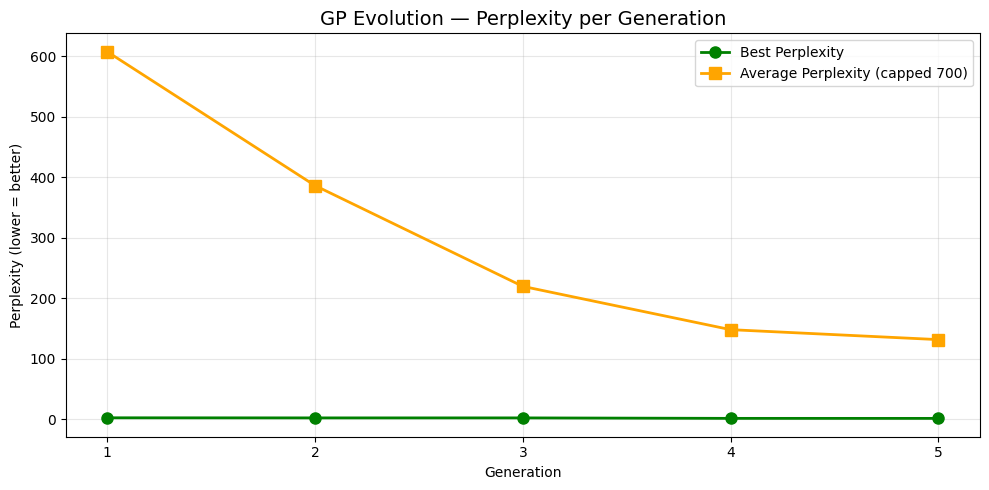

Graph 1 saved!


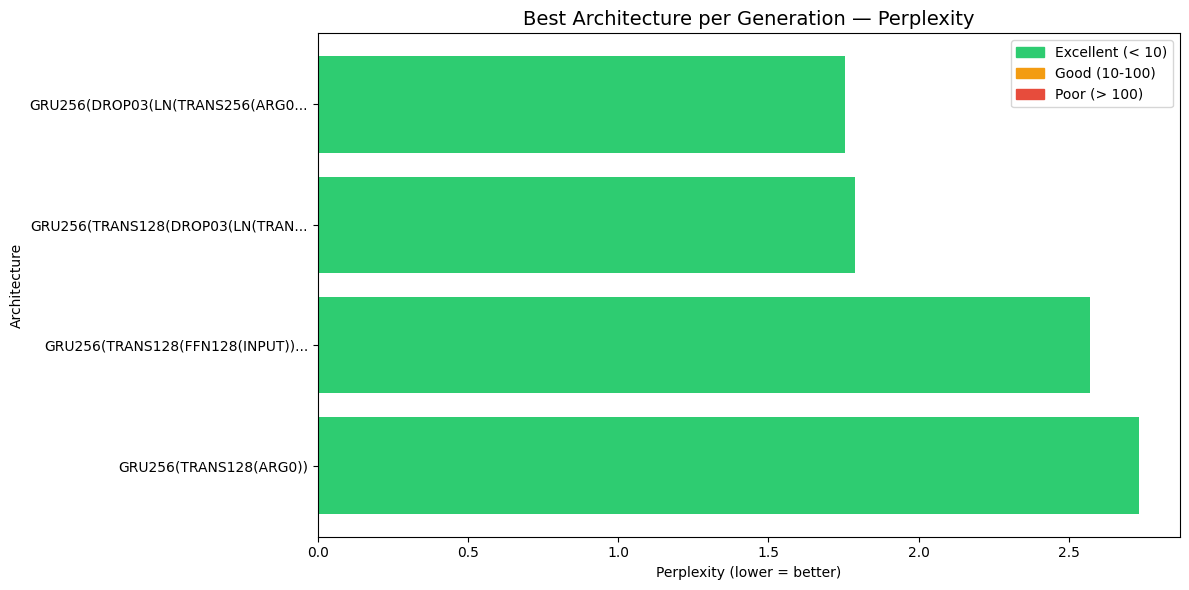

Graph 2 saved!


In [11]:
# Cell 13b — GP Evolution Graphs
# Loads evolution log and generates graphs instantly
# No model inference needed — just plotting saved logs

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

# --- Load Evolution Log ---
with open(f"{LOGS_DIR}/gp_evolution_log.json", "r") as f:
    gen_logs = json.load(f)

print(f"Generations loaded: {len(gen_logs)}")

generations = [log["generation"]      for log in gen_logs]
best_perps  = [log["best_perplexity"] for log in gen_logs]
avg_perps   = [min(log["avg_perplexity"], 700) for log in gen_logs]

# --- Graph 1 — GP Evolution Perplexity per Generation ---
plt.figure(figsize=(10, 5))
plt.plot(generations, best_perps, marker='o', color='green',
         linewidth=2, markersize=8, label='Best Perplexity')
plt.plot(generations, avg_perps,  marker='s', color='orange',
         linewidth=2, markersize=8, label='Average Perplexity (capped 700)')
plt.title('GP Evolution — Perplexity per Generation', fontsize=14)
plt.xlabel('Generation')
plt.ylabel('Perplexity (lower = better)')
plt.xticks(generations)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{LOGS_DIR}/graph_gp_evolution.png", dpi=150)
plt.show()
print("Graph 1 saved!")

# --- Graph 2 — Best Architecture per Generation Bar Chart ---
trees  = [log["best_tree"][:30] + "..."
          if len(log["best_tree"]) > 30
          else log["best_tree"]
          for log in gen_logs]
colors = ['#2ecc71' if p < 10
          else '#f39c12' if p < 100
          else '#e74c3c'
          for p in best_perps]

plt.figure(figsize=(12, 6))
plt.barh(trees, best_perps, color=colors)
plt.title('Best Architecture per Generation — Perplexity', fontsize=14)
plt.xlabel('Perplexity (lower = better)')
plt.ylabel('Architecture')

green_patch  = mpatches.Patch(color='#2ecc71', label='Excellent (< 10)')
orange_patch = mpatches.Patch(color='#f39c12', label='Good (10-100)')
red_patch    = mpatches.Patch(color='#e74c3c', label='Poor (> 100)')
plt.legend(handles=[green_patch, orange_patch, red_patch])
plt.tight_layout()
plt.savefig(f"{LOGS_DIR}/graph_best_per_generation.png", dpi=150)
plt.show()
print("Graph 2 saved!")

Training epochs loaded: 5


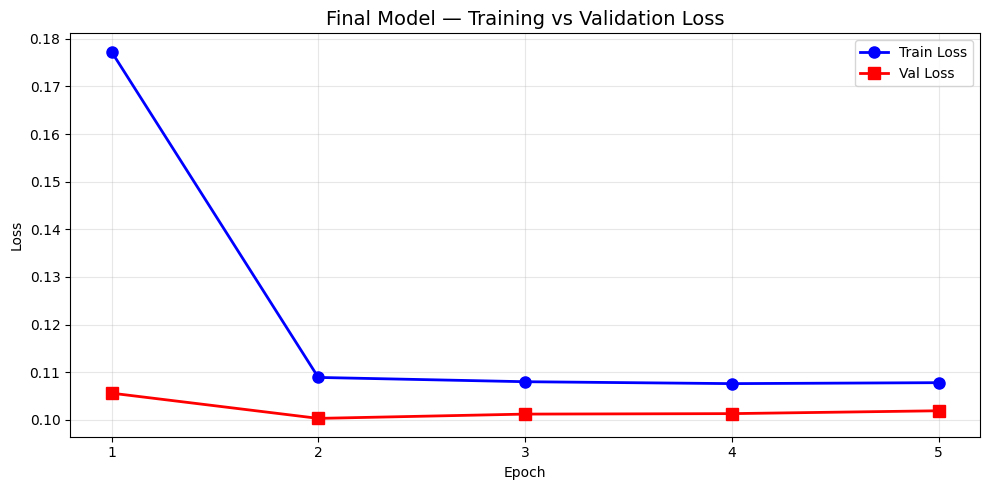

Graph 1 saved!


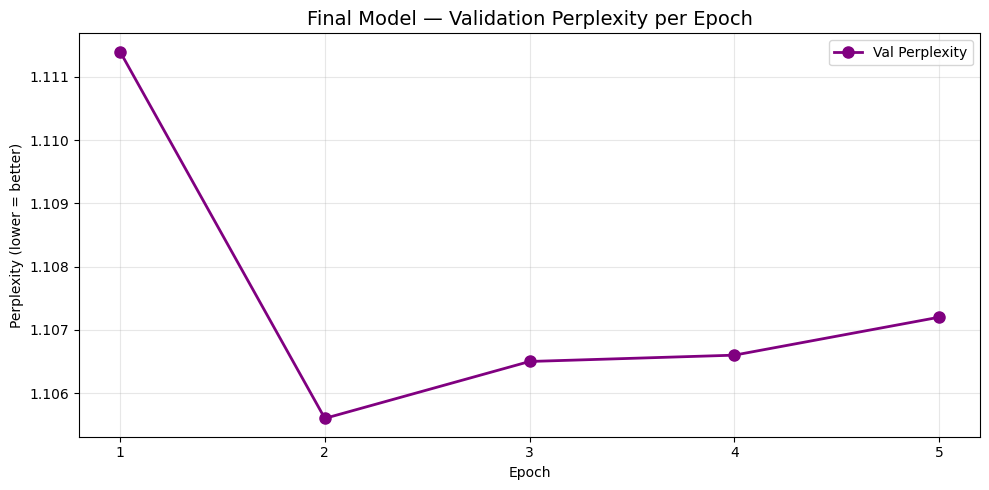

Graph 2 saved!

  TRAINING SUMMARY
Total epochs trained : 5
Best Val Loss        : 0.1003
Best Val Perplexity  : 1.1056
Final Train Loss     : 0.1078

Run Cell 14 for Live Top 3 Prediction Demo!


In [12]:
# Cell 13c — Training Loss + Perplexity Graphs
# Loads final training log and generates training curves
# No model inference needed — just plotting saved logs

import matplotlib.pyplot as plt
import json
import math

# --- Load Training Log ---
with open(f"{LOGS_DIR}/final_training_log.json", "r") as f:
    training_log = json.load(f)

print(f"Training epochs loaded: {len(training_log)}")

epochs      = [log["epoch"]          for log in training_log]
train_losses= [log["train_loss"]     for log in training_log]
val_losses  = [log["val_loss"]       for log in training_log]
val_perps   = [log["val_perplexity"] for log in training_log]

# --- Graph 1 — Training vs Validation Loss ---
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, marker='o', color='blue',
         linewidth=2, markersize=8, label='Train Loss')
plt.plot(epochs, val_losses,   marker='s', color='red',
         linewidth=2, markersize=8, label='Val Loss')
plt.title('Final Model — Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{LOGS_DIR}/graph_training_loss.png", dpi=150)
plt.show()
print("Graph 1 saved!")

# --- Graph 2 — Validation Perplexity per Epoch ---
plt.figure(figsize=(10, 5))
plt.plot(epochs, val_perps, marker='o', color='purple',
         linewidth=2, markersize=8, label='Val Perplexity')
plt.title('Final Model — Validation Perplexity per Epoch', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Perplexity (lower = better)')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{LOGS_DIR}/graph_val_perplexity.png", dpi=150)
plt.show()
print("Graph 2 saved!")

# --- Summary ---
print("\n" + "="*50)
print("  TRAINING SUMMARY")
print("="*50)
print(f"Total epochs trained : {len(training_log)}")
print(f"Best Val Loss        : {min(val_losses):.4f}")
print(f"Best Val Perplexity  : {min(val_perps):.4f}")
print(f"Final Train Loss     : {train_losses[-1]:.4f}")
print("\nRun Cell 14 for Live Top 3 Prediction Demo!")

In [13]:
# Cell 14 — Live Top 3 Next Word Prediction Demo (Fixed Version)
# Fix 1: Removed .lower() — preserves capitalization for proper token matching
# Fix 2: Minimum 5 words required for meaningful predictions
# Fix 3: Shows unknown word warning if any input word not in vocab
# Fix 4: Suggests capitalization fix if <unk> detected in predictions

import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Step 1: Prediction Function ---
def predict_next_words(input_text, model, word2idx, idx2word,
                       top_k=3, seq_len=64):
    model.eval()

    # Fix 1: No .lower() — preserve original capitalization
    tokens  = input_text.strip().split()

    # Check for unknown words and warn user
    unknown = [t for t in tokens if t not in word2idx]
    if unknown:
        print(f"\n  ⚠️  Unknown words detected: {unknown}")
        print(f"  These will be treated as <unk>.")
        print(f"  Try capitalizing properly e.g. 'London' not 'london'")

    # Convert to indices
    indices = [word2idx.get(t, word2idx['<unk>']) for t in tokens]

    # Pad to seq_len
    if len(indices) < seq_len:
        indices = [word2idx['<pad>']] * (seq_len - len(indices)) + indices
    else:
        indices = indices[-seq_len:]

    # Convert to tensor
    x = torch.tensor([indices], dtype=torch.long).to(device)

    # Forward pass
    with torch.no_grad():
        logits = model(x)

    # Get last token predictions
    last_logits = logits[0, -1, :]

    # Remove <unk> and <pad> from predictions
    last_logits[word2idx['<unk>']] = float('-inf')
    last_logits[word2idx['<pad>']] = float('-inf')

    # Get top k probabilities
    probs                          = F.softmax(last_logits, dim=-1)
    top_probs, top_indices         = torch.topk(probs, top_k)

    results = []
    for prob, idx in zip(top_probs.tolist(), top_indices.tolist()):
        word = idx2word.get(idx, '<unk>')
        results.append((word, prob * 100))

    return results

# --- Step 2: Display Function ---
def display_predictions(input_text, predictions):
    print("\n" + "="*55)
    print(f"  Input : '{input_text}'")
    print("="*55)
    print(f"  Top 3 Next Word Predictions:")
    print("-"*55)
    for rank, (word, prob) in enumerate(predictions, 1):
        bar    = "█" * int(prob / 2)
        print(f"  {rank}. {word:<25} {prob:>6.2f}%  {bar}")
    print("="*55)

# --- Step 3: Vocab Helper ---
def check_vocab(text, word2idx):
    """Shows which words are in vocab and which are not"""
    tokens = text.strip().split()
    print("\n  Vocab Check:")
    for t in tokens:
        status = "✅" if t in word2idx else "❌ unknown"
        print(f"  {t:<20} {status}")

# --- Step 4: Live Demo Loop ---
print("="*55)
print("  GP-EVOLVED MODEL — LIVE PREDICTION DEMO")
print("  Architecture : GRU256(DROP03(LN(TRANS256)))")
print(f"  Val Perplexity : 1.1114")
print("="*55)
print("\n  Tips for best predictions:")
print("  1. Use at least 5 words")
print("  2. Use proper capitalization (London not london)")
print("  3. Type 'check: your text' to verify vocab")
print("  4. Type 'quit' to exit")
print()

while True:
    try:
        user_input = input("Your input: ").strip()

        # Exit
        if user_input.lower() == 'quit':
            print("\nExiting prediction demo!")
            break

        # Empty input
        if user_input == '':
            print("  Please enter some text!")
            continue

        # Vocab check mode
        if user_input.startswith('check:'):
            text = user_input.replace('check:', '').strip()
            check_vocab(text, word2idx)
            continue

        # Minimum word check
        if len(user_input.split()) < 5:
            print("\n  Please enter at least 5 words for better predictions!")
            print("  Example: 'The stock market in London'")
            continue

        # Predict
        predictions = predict_next_words(
                        user_input, final_model,
                        word2idx, idx2word, top_k=3)

        display_predictions(user_input, predictions)

    except KeyboardInterrupt:
        print("\nExiting prediction demo!")
        break

  GP-EVOLVED MODEL — LIVE PREDICTION DEMO
  Architecture : GRU256(DROP03(LN(TRANS256)))
  Val Perplexity : 1.1114

  Tips for best predictions:
  1. Use at least 5 words
  2. Use proper capitalization (London not london)
  3. Type 'check: your text' to verify vocab
  4. Type 'quit' to exit

Your input: The London bridge is falling

  Input : 'The London bridge is falling'
  Top 3 Next Word Predictions:
-------------------------------------------------------
  1. krist                      12.28%  ██████
  2. unit                        5.73%  ██
  3. batteries                   5.18%  ██
Your input: High

  Please enter at least 5 words for better predictions!
  Example: 'The stock market in London'
Your input: quit

Exiting prediction demo!
